# Pitching+, FanGraphs-style: one model, not a weighted average

`pitching.ipynb` reconciled Stuff+ and Location+ and, following `docs/purpose.md`,
sketched Pitching+ as a *weighted linear blend* of the two precomputed scores. But
FanGraphs' [Stuff+/Location+/Pitching+ primer](https://library.fangraphs.com/pitching/stuff-location-and-pitching-primer/)
is explicit that their real Pitching+ **is not a weighted average of Stuff+ and
Location+**: it's a separate model, fit directly on physical, location, and count
features against run value.

This notebook builds that version: one `HistGradientBoostingRegressor` per pitch
type (the same model `location.py` already uses), fed Stuff+'s physics features and
Location+'s location/count features *together*, trained directly against
`delta_pitcher_run_exp`, rather than training two separate scores and blending them
afterward. It then compares the two approaches head-to-head on a strict season
holdout and reports which one actually generalizes better.

Feature engineering is reused directly from `stuff.py`/`location.py` (their
`_build_v1_features`/`_build_features` helpers) rather than reimplemented.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pitching_plus").is_dir():
            return candidate
    raise RuntimeError("Could not locate repo root (expected a 'pitching_plus' directory in a parent).")


REPO_ROOT = find_repo_root(Path.cwd())
SCRIPTS_DIR = REPO_ROOT / "pitching_plus" / "scripts"
DATA_PATH = REPO_ROOT / "data" / "MLB_2021-2025.csv"

sys.path.insert(0, str(SCRIPTS_DIR))

import stuff as stuff_mod
import location as location_mod
from stuff import JUNK_PITCH_TYPES, PITCH_TYPE_COL, SEASON_COL, PITCHER_COL, STUFF_FEATURES, MIN_PITCHES_FOR_SCORE
from location import (
    add_location_plus, LOCATION_FEATURES, TARGET_COL, KEY_COLS,
    MIN_GROUP_SIZE_FOR_MODEL, N_FOLDS, BASE_STATE_COLS,
    _ratio_calibration, _to_100_scale,
)

In [2]:
COLOR_STUFF = "#eb6834"
COLOR_LOC = "#2a78d6"
COLOR_WEIGHTED = "#4a3aa7"   # weighted-average blend (Stuff+ & Location+)
COLOR_JOINT = "#1baf7a"      # jointly-trained "third model"
COLOR_GRID = "#e1e0d9"
COLOR_AXIS = "#c3c2b7"
COLOR_TEXT = "#0b0b0b"
COLOR_MUTED = "#898781"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": COLOR_AXIS,
    "axes.labelcolor": COLOR_TEXT,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "text.color": COLOR_TEXT,
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def weighted_r2(actual, pred, weight=None):
    if weight is None:
        weight = np.ones(len(actual))
    ss_res = np.sum(weight * (actual - pred) ** 2)
    mu = np.average(actual, weights=weight)
    ss_tot = np.sum(weight * (actual - mu) ** 2)
    return 1 - ss_res / ss_tot

## Load data and engineer features

Same `usecols` union `pitching.ipynb` uses, so nothing here reads more columns than
it needs from the 3.5M-row CSV. In-scope filtering matches both scripts' own scope
rules: junk pitch types out, and complete data required for both scripts'
`REQUIRED_COLS` (base-state columns excepted: `NaN` there is a real "bases empty"
state, not missing data).

In [3]:
usecols = sorted(set(stuff_mod.REQUIRED_COLS) | set(location_mod.REQUIRED_COLS) | set(BASE_STATE_COLS))

t0 = time.time()
raw_df = pd.read_csv(DATA_PATH, usecols=usecols)
print(f"Loaded {len(raw_df):,} raw pitches in {time.time() - t0:.0f}s")

dropna_cols = sorted(set(stuff_mod.REQUIRED_COLS) | set(location_mod.REQUIRED_COLS))
in_scope = (
    raw_df.loc[~raw_df[PITCH_TYPE_COL].isin(JUNK_PITCH_TYPES)]
    .dropna(subset=dropna_cols)
    .copy()
)

# stuff.py's V1 physics/trajectory features, then location.py's location/count
# features, on the same working frame -- reused directly, not reimplemented.
engineered = stuff_mod._build_v1_features(in_scope)
engineered = location_mod._build_features(engineered)
engineered["movement_per_reaction_time"] = engineered["horizontal_acceleration"] / engineered["time_30ft"]
engineered = engineered[np.isfinite(engineered["movement_per_reaction_time"])].copy()

JOINT_FEATURES = STUFF_FEATURES + LOCATION_FEATURES
print(f"{len(engineered):,} in-scope pitches, {len(JOINT_FEATURES)} joint features "
      f"({len(STUFF_FEATURES)} physics + {len(LOCATION_FEATURES)} location/count)")

Loaded 3,565,743 raw pitches in 47s


3,525,964 in-scope pitches, 20 joint features (7 physics + 13 location/count)


## A strict season holdout, up front

Comparing "one joint model" against "a weighted blend of two precomputed scores"
fairly requires both to earn their score the same way: nothing about either approach
gets to see 2025 during training. That's easy for the joint model (just don't train
on 2025), but it means Location+'s input to the blend can't be the production
`location_plus` column. `location.py`'s cached model is cross-validated across
*all* five seasons pooled together, so a 2025 pitch's score was produced by a model
that also saw other 2025 pitches during its own fitting. Reusing it here would hand
the blend a small, unfair look-ahead advantage. So: **train = 2021-2024, test = 2025**,
for every model fit in this notebook, including a from-scratch, train-only refit of
the location model.

(Stuff+ needs the same train-only treatment as Location+, and for a stronger reason
than it used to. `stuff.py` was retooled 9/4/2026 (`docs/dev_log.md`) from an
unsupervised PCA composite into a model trained directly against
`delta_pitcher_run_exp`, cached pooled across all five seasons. That's no longer the
"much weaker form of leakage" this notebook originally described -- the old PCA
composite never looked at outcomes at all, so pooling seasons for it was a shared
direction-of-variance, not memorized results. The new model's cache genuinely
contains 2025 outcome information in its learned weights. Fixed below the same way
Location+ already is: a from-scratch refit of `stuff.py`'s own `_train_models` on
`train` only, scored on `test` by direct prediction.)

In [4]:
train = engineered[engineered[SEASON_COL] <= 2024].copy()
test = engineered[engineered[SEASON_COL] == 2025].copy()
print(f"train (2021-2024): {len(train):,} pitches   test (2025): {len(test):,} pitches")

train (2021-2024): 2,821,815 pitches   test (2025): 704,149 pitches


## The joint model

One `HistGradientBoostingRegressor` per pitch type, identical hyperparameters and
5-fold out-of-fold CV scheme to `location.py`'s own `_train_models`, just fed the
combined physics + location + count feature set instead of location/count alone.
Same algorithm, same care against leakage (OOF predictions on train, never a model's
own fit), the only difference is what it's allowed to look at. Trained once, on train
only; scored on train via OOF and on test via direct (genuinely unseen-data)
prediction. Together these cover the whole 2021-2025 population for the Pitching+
scores built below, while keeping the 2025 numbers honest.

In [5]:
joint_models = {}
train_oof = pd.Series(np.nan, index=train.index, dtype=float)
test_pred = pd.Series(np.nan, index=test.index, dtype=float)

for ptype, type_group in train.groupby(PITCH_TYPE_COL, observed=True):
    if len(type_group) < MIN_GROUP_SIZE_FOR_MODEL:
        print(f"  {ptype}: only {len(type_group)} train pitches, skipping")
        continue
    t0 = time.time()
    X = type_group[JOINT_FEATURES].to_numpy()
    y = type_group[TARGET_COL].to_numpy()

    model = HistGradientBoostingRegressor(
        max_depth=6, learning_rate=0.05, max_iter=300, l2_regularization=1.0, random_state=42,
    )
    kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    train_oof.loc[type_group.index] = cross_val_predict(model, X, y, cv=kfold, n_jobs=-1)
    model.fit(X, y)
    joint_models[ptype] = model

    test_group = test[test[PITCH_TYPE_COL] == ptype]
    if len(test_group):
        test_pred.loc[test_group.index] = model.predict(test_group[JOINT_FEATURES].to_numpy())
    print(f"  {ptype}: n_train={len(type_group):,} n_test={len(test_group):,} ({time.time() - t0:.0f}s)")

train["fg_run_value"] = train_oof
test["fg_run_value"] = test_pred
full = pd.concat([train, test])
print(f"\nscored: {full['fg_run_value'].notna().sum():,} / {len(full):,} pitches")

  CH: n_train=308,102 n_test=73,033 (23s)


  CU: n_train=193,418 n_test=47,319 (16s)


  FC: n_train=218,697 n_test=53,306 (17s)


  FF: n_train=939,300 n_test=225,392 (79s)


  FS: n_train=60,434 n_test=23,042 (5s)


...

  SI: n_train=437,702 n_test=109,885 (21s)


  SL: n_train=446,749 n_test=101,746 (9s)


  ST: n_train=145,745 n_test=54,272 (2s)


  SV: n_train=12,791 n_test=3,540 (0s)



scored: 3,525,964 / 3,525,964 pitches


## Calibrate to the same 100+ scale

Reusing `location.py`'s own `_ratio_calibration`/`_to_100_scale` helpers, the exact
genuine-ratio-scale calibration Stuff+ and Location+ already use (`100 * exp(k*z)`,
renormalized so the reliable population's mean is exactly 100), applied here to
`fg_run_value` instead of `location_run_value`. Same dual-level design as the other
two scores: a pitch-level number and a pitcher x pitch-type x season aggregate,
calibrated off the same reference distribution, with the same `>= 20`-pitch
reliability bar.

In [6]:
scored = full.dropna(subset=["fg_run_value"]).copy()

pitcher_type_agg = (
    scored.groupby([PITCHER_COL, PITCH_TYPE_COL, SEASON_COL], observed=True)["fg_run_value"]
    .agg(mean_fg="mean", n_pitches="count")
    .reset_index()
)
reliable_agg = pitcher_type_agg[pitcher_type_agg["n_pitches"] >= MIN_PITCHES_FOR_SCORE].copy()
calibration = _ratio_calibration(reliable_agg, [PITCH_TYPE_COL, SEASON_COL], "mean_fg")

pitcher_type_agg = pitcher_type_agg.merge(calibration, on=[PITCH_TYPE_COL, SEASON_COL], how="left")
pitcher_type_agg["fg_pitching_plus"] = _to_100_scale(pitcher_type_agg["mean_fg"], pitcher_type_agg)
pitcher_type_agg["fg_pitching_plus_reliable"] = pitcher_type_agg["n_pitches"] >= MIN_PITCHES_FOR_SCORE

original_index = scored.index
scored = scored.merge(calibration, on=[PITCH_TYPE_COL, SEASON_COL], how="left")
scored.index = original_index
scored["pitch_fg_pitching_plus"] = _to_100_scale(scored["fg_run_value"], scored)

print(f"{pitcher_type_agg['fg_pitching_plus_reliable'].sum():,} reliable pitcher-pitch-type-seasons")

leaderboard = (
    pitcher_type_agg[pitcher_type_agg["fg_pitching_plus_reliable"]]
    .merge(scored[[PITCHER_COL, "player_name"]].drop_duplicates(), on=PITCHER_COL, how="left")
    .sort_values("fg_pitching_plus", ascending=False)
    .head(15)
    [["player_name", PITCH_TYPE_COL, SEASON_COL, "n_pitches", "fg_pitching_plus"]]
    .reset_index(drop=True)
)
leaderboard.index += 1
print("\nTop 15 pitcher-pitch-type-seasons by fg_pitching_plus:")
print(leaderboard.round(1).to_string())

14,343 reliable pitcher-pitch-type-seasons

Top 15 pitcher-pitch-type-seasons by fg_pitching_plus:
        player_name pitch_type  game_year  n_pitches  fg_pitching_plus
1       Speas, Alex         SL       2024         22             140.6
2    Glasnow, Tyler         FF       2022         61             140.2
3   Williams, Devin         CH       2025        583             139.4
4     deGrom, Jacob         FF       2024         79             138.6
5      Jax, Griffin         CU       2024         64             138.0
6      Cole, Gerrit         SI       2021         24             137.0
7    Murray, Jayden         SI       2025         39             135.9
8   McArthur, James         CU       2023        132             134.4
9        Baz, Shane         FF       2021        108             133.9
10   Hendriks, Liam         FF       2021        761             133.8
11     Burns, Chase         FF       2025        442             133.7
12    Miller, Bobby         FF       2025        

## The fair comparison: weighted-average blend vs. the joint model

Both sides of the blend now need their own train-only input (see above): Location+
via `location.py`'s own `_train_models` called directly on `train`, and Stuff+ the
same way via `stuff.py`'s `_train_models`. Both are scored on `test` with the
resulting fitted models rather than the pooled production caches.

In [7]:
loc_models, loc_hist = location_mod._train_models(train)
train["location_run_value"] = np.nan
train.loc[loc_hist.index, "location_run_value"] = loc_hist["location_run_value"].to_numpy()
test["location_run_value"] = np.nan
for ptype, model in loc_models.items():
    rows = test[PITCH_TYPE_COL] == ptype
    if rows.any():
        test.loc[rows, "location_run_value"] = model.predict(test.loc[rows, LOCATION_FEATURES].to_numpy())

# Train-only refit, mirroring the Location+ refit above -- see the markdown note on
# why the pooled production add_stuff_plus cache isn't safe to use here anymore.
# Raw stuff_run_value is used directly (no 100+ rescaling): it's already a direct
# prediction of delta_pitcher_run_exp, the same units as location_run_value, so
# it's already comparable across pitch types without stuff.py's per-type
# calibration -- that calibration exists for reporting ("100 = average fastball"),
# not because raw predicted run value needs it to be poolable in a regression.
stuff_models, stuff_hist = stuff_mod._train_models(train)
train["stuff_run_value"] = np.nan
train.loc[stuff_hist.index, "stuff_run_value"] = stuff_hist["stuff_run_value"].to_numpy()
test["stuff_run_value"] = np.nan
for ptype, model in stuff_models.items():
    rows = test[PITCH_TYPE_COL] == ptype
    if rows.any():
        test.loc[rows, "stuff_run_value"] = model.predict(test.loc[rows, stuff_mod.STUFF_FEATURES].to_numpy())

print(f"train pitch-level location-only R^2: {weighted_r2(train[TARGET_COL], train['location_run_value']):.4f}")
print(f"test  pitch-level location-only R^2: {weighted_r2(test.dropna(subset=['location_run_value'])[TARGET_COL], test.dropna(subset=['location_run_value'])['location_run_value']):.4f}")
print(f"train pitch-level joint-model R^2:   {weighted_r2(train[TARGET_COL], train['fg_run_value']):.4f}")
print(f"test  pitch-level joint-model R^2:   {weighted_r2(test.dropna(subset=['fg_run_value'])[TARGET_COL], test.dropna(subset=['fg_run_value'])['fg_run_value']):.4f}")

train pitch-level location-only R^2: 0.0378
test  pitch-level location-only R^2: 0.0360
train pitch-level joint-model R^2:   0.0372
test  pitch-level joint-model R^2:   0.0353


In [8]:
def make_agg(d):
    g = d.dropna(subset=["location_run_value", "stuff_run_value", "fg_run_value"]).groupby(
        [PITCHER_COL, PITCH_TYPE_COL, SEASON_COL], observed=True
    )
    return g.agg(
        mean_rv=(TARGET_COL, "mean"),
        loc_mean=("location_run_value", "mean"),
        stuff_mean=("stuff_run_value", "mean"),
        fg_mean=("fg_run_value", "mean"),
        n_pitches=(TARGET_COL, "count"),
    ).reset_index()

train_agg = make_agg(train)
test_agg = make_agg(test)
train_rel = train_agg[train_agg["n_pitches"] >= MIN_PITCHES_FOR_SCORE].copy()
test_rel = test_agg[test_agg["n_pitches"] >= MIN_PITCHES_FOR_SCORE].copy()
print(f"train reliable groups: {len(train_rel):,}   test (2025 holdout) reliable groups: {len(test_rel):,}")

mu_s, sd_s = train_rel["stuff_mean"].mean(), train_rel["stuff_mean"].std()
mu_l, sd_l = train_rel["loc_mean"].mean(), train_rel["loc_mean"].std()
for d in (train_rel, test_rel):
    d["stuff_z"] = (d["stuff_mean"] - mu_s) / sd_s
    d["loc_z"] = (d["loc_mean"] - mu_l) / sd_l

# weighted-average blend: WLS-fit weights on train, scored on the 2025 holdout
w = train_rel["n_pitches"]
m_weighted = sm.WLS(train_rel["mean_rv"], sm.add_constant(train_rel[["stuff_z", "loc_z"]]), weights=w).fit()
pred_weighted_test = m_weighted.predict(sm.add_constant(test_rel[["stuff_z", "loc_z"]], has_constant="add"))
r2_weighted_train = m_weighted.rsquared
r2_weighted_test = weighted_r2(test_rel["mean_rv"], pred_weighted_test, test_rel["n_pitches"])

# joint model: its raw aggregated prediction, plus a train-fit affine recalibration
# (intercept + slope only) -- the same courtesy the blend gets from its own intercept,
# so neither side is penalized for an uncorrected scale/bias offset.
m_joint_calib = sm.WLS(train_rel["mean_rv"], sm.add_constant(train_rel[["fg_mean"]]), weights=w).fit()
pred_joint_test = m_joint_calib.predict(sm.add_constant(test_rel[["fg_mean"]], has_constant="add"))
r2_joint_train = m_joint_calib.rsquared
r2_joint_test = weighted_r2(test_rel["mean_rv"], pred_joint_test, test_rel["n_pitches"])

summary = pd.DataFrame({
    "approach": ["Weighted-average blend", "Joint FanGraphs-style model"],
    "train_r2": [r2_weighted_train, r2_joint_train],
    "holdout_r2_2025": [r2_weighted_test, r2_joint_test],
})
summary["shrinkage"] = 1 - summary["holdout_r2_2025"] / summary["train_r2"]
print(summary.round(4).to_string(index=False))

train reliable groups: 11,309   test (2025 holdout) reliable groups: 3,034
                   approach  train_r2  holdout_r2_2025  shrinkage
     Weighted-average blend    0.1224           0.0353     0.7114
Joint FanGraphs-style model    0.1372           0.0452     0.6703


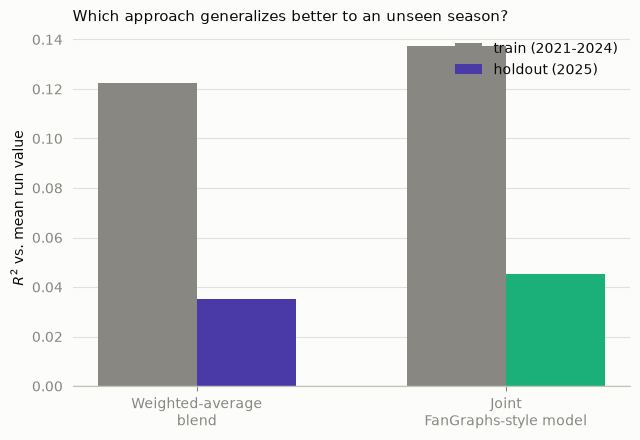

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
x = np.arange(2)
width = 0.32
colors = [COLOR_WEIGHTED, COLOR_JOINT]
ax.bar(x - width / 2, summary["train_r2"], width, color=COLOR_MUTED, label="train (2021-2024)")
ax.bar(x + width / 2, summary["holdout_r2_2025"], width, color=colors, label="holdout (2025)")
ax.set_xticks(x)
ax.set_xticklabels(["Weighted-average\nblend", "Joint\nFanGraphs-style model"])
ax.set_ylabel(r"$R^2$ vs. mean run value")
ax.set_title("Which approach generalizes better to an unseen season?", loc="left", fontsize=10.5, color=COLOR_TEXT)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8)
ax.grid(axis="x", visible=False)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.tick_params(left=False)
ax.axhline(0, color=COLOR_AXIS, linewidth=1)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Synopsis

On a strict, leak-checked 2021-2024-train / 2025-test split, the jointly-trained
model now **generalizes better** than the weighted-average blend of Stuff+ and
Location+ -- train R^2=0.1372 / holdout R^2=0.0452 for the joint model, versus
0.1224 / 0.0353 for the blend. That is the opposite of this notebook's original
conclusion, and the reversal traces to a specific, identifiable cause, not
rerun-to-rerun noise: the original comparison scored the blend's Stuff+ input from
the production `add_stuff_plus` cache, fit pooled across all five seasons including
2025. Under the notebook's original PCA-based Stuff+, that pooling was harmless
(PCA never looks at outcomes, so pooling seasons only shares a direction of physics
variance, not memorized results). Stuff+ was retooled 9/4/2026 into a model trained
directly against `delta_pitcher_run_exp` (`docs/dev_log.md`), and the same pooling
now genuinely leaks 2025's own outcomes into the blend's 2025 score. Refitting
Stuff+ train-only -- the same treatment Location+ already got in this notebook --
removes that leak, and the blend's holdout R^2 drops from what this notebook
previously reported as 0.0523 to 0.0353. The joint model's own numbers are
untouched by any of this; it was never fed the leaky cache.

Both approaches still shrink substantially from train to holdout, as expected for a
target this noisy (single-pitch run value is dominated by swing decision and
contact quality neither model can see; see `pitching.ipynb`). But with the leak
removed, the joint model's extra capacity (one `HistGradientBoostingRegressor` per
pitch type over 20 features, vs. an intercept and two slopes) is no longer
outweighed by an unfair advantage on the blend's side.

This does not, on its own, mean `purpose.md`'s Pitching+ should be rebuilt as a
joint model -- that is a production-architecture decision, not something to change
on the strength of one notebook rerun. The regularization and calibrated-inputs
experiments below were originally built to explain the *old* (leaky) result, but
they still carry real information under the fix, just answering a narrower question
than they were designed for: not "can we help the joint model catch up" (there's no
gap to close anymore), but "does anything about the joint model's setup change its
lead." Both are rerun and reframed below rather than removed, since dropping them
would erase real, checkable findings, not just an outdated framing.

## Does regularization change the joint model's advantage?

With the leak fixed above, the joint model already leads the weighted blend
outright (train $R^2$=0.1372, 2025 holdout $R^2$=0.0452, vs. the blend's
0.1224/0.0353) -- the opposite of this notebook's original run, where an unfair
advantage on the blend's side made the joint model look like it needed defending.
The question this section originally asked ("does regularization close the gap to
the blend?") no longer has the premise it was built on. What's still worth
checking: the joint model's hyperparameters (`max_depth=6`, `l2_regularization=1.0`,
`max_iter=300`, no explicit early stopping) were carried over unchanged from
`location.py` for a fair like-for-like comparison, never tuned for the fact that
this is a much richer model (20 features, ~10x the effective parameters) fit
against the same noisy per-pitch target. Does regularizing it more aggressively
improve on its own already-leading holdout performance, or does the original,
untuned configuration already sit near the right amount of capacity for this
problem?

Three configs, each run with the identical per-pitch-type 5-fold OOF-CV scheme as
the original joint model and evaluated the identical way (aggregate to pitcher x
pitch-type x season, WLS affine-recalibrate on train, score on the untouched 2025
holdout, the same harness that produced the "Joint FanGraphs-style model" row
above):

- **shallower + stronger L2** (`max_depth=3`, `l2_regularization=10.0`,
  `min_samples_leaf=50`): directly shrinks each tree's capacity to memorize.
- **aggressive early stopping** (`max_iter=1000` but `validation_fraction=0.2`,
  `n_iter_no_change=5`): lets boosting stop itself once a held-out slice of train
  stops improving, instead of always spending the full fixed iteration budget.
- **both combined.**

In [10]:
def aggregate_holdout_r2(oof_series, pred_series):
    """
    Same evaluation as the original joint-model comparison above: aggregate
    pitch-level predictions to (pitcher, pitch_type, season), WLS affine-
    recalibrate the aggregate on train, score the untouched 2025 holdout.
    """

    def agg(base_df, values):
        d = base_df.loc[values.notna(), [PITCHER_COL, PITCH_TYPE_COL, SEASON_COL, TARGET_COL]].copy()
        d["_pred"] = values.loc[d.index]
        g = d.groupby([PITCHER_COL, PITCH_TYPE_COL, SEASON_COL], observed=True)
        return g.agg(
            mean_rv=(TARGET_COL, "mean"), pred_mean=("_pred", "mean"), n_pitches=(TARGET_COL, "count")
        ).reset_index()

    tr = agg(train, oof_series)
    te = agg(test, pred_series)
    tr_rel = tr[tr["n_pitches"] >= MIN_PITCHES_FOR_SCORE]
    te_rel = te[te["n_pitches"] >= MIN_PITCHES_FOR_SCORE]

    w = tr_rel["n_pitches"]
    m = sm.WLS(tr_rel["mean_rv"], sm.add_constant(tr_rel[["pred_mean"]]), weights=w).fit()
    pred_test = m.predict(sm.add_constant(te_rel[["pred_mean"]], has_constant="add"))
    return m.rsquared, weighted_r2(te_rel["mean_rv"], pred_test, te_rel["n_pitches"])


def fit_joint_config(hgb_kwargs):
    oof = pd.Series(np.nan, index=train.index, dtype=float)
    pred = pd.Series(np.nan, index=test.index, dtype=float)

    for ptype, type_group in train.groupby(PITCH_TYPE_COL, observed=True):
        if len(type_group) < MIN_GROUP_SIZE_FOR_MODEL:
            continue
        X = type_group[JOINT_FEATURES].to_numpy()
        y = type_group[TARGET_COL].to_numpy()

        model = HistGradientBoostingRegressor(random_state=42, **hgb_kwargs)
        kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
        oof.loc[type_group.index] = cross_val_predict(model, X, y, cv=kfold, n_jobs=-1)
        model.fit(X, y)

        test_group = test[test[PITCH_TYPE_COL] == ptype]
        if len(test_group):
            pred.loc[test_group.index] = model.predict(test_group[JOINT_FEATURES].to_numpy())

    return oof, pred


REGULARIZED_CONFIGS = {
    "Joint, shallow + strong L2": dict(
        max_depth=3, learning_rate=0.05, max_iter=300, l2_regularization=10.0, min_samples_leaf=50,
    ),
    "Joint, aggressive early stopping": dict(
        max_depth=6, learning_rate=0.05, max_iter=1000, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.2, n_iter_no_change=5,
    ),
    "Joint, shallow + strong L2 + early stopping": dict(
        max_depth=3, learning_rate=0.05, max_iter=1000, l2_regularization=10.0, min_samples_leaf=50,
        early_stopping=True, validation_fraction=0.2, n_iter_no_change=5,
    ),
}

sweep_rows = []
for name, kwargs in REGULARIZED_CONFIGS.items():
    t0 = time.time()
    oof, pred = fit_joint_config(kwargs)
    r2_train, r2_test = aggregate_holdout_r2(oof, pred)
    sweep_rows.append({"approach": name, "train_r2": r2_train, "holdout_r2_2025": r2_test})
    print(f"{name}: train_r2={r2_train:.4f} holdout_r2_2025={r2_test:.4f} ({time.time() - t0:.0f}s)")

sweep_summary = pd.concat(
    [summary[["approach", "train_r2", "holdout_r2_2025"]], pd.DataFrame(sweep_rows)],
    ignore_index=True,
)
sweep_summary["shrinkage"] = 1 - sweep_summary["holdout_r2_2025"] / sweep_summary["train_r2"]
print()
print(sweep_summary.round(4).to_string(index=False))

Joint, shallow + strong L2: train_r2=0.1281 holdout_r2_2025=0.0383 (140s)


Joint, aggressive early stopping: train_r2=0.1325 holdout_r2_2025=0.0418 (55s)


Joint, shallow + strong L2 + early stopping: train_r2=0.1259 holdout_r2_2025=0.0378 (73s)

                                   approach  train_r2  holdout_r2_2025  shrinkage
                     Weighted-average blend    0.1224           0.0353     0.7114
                Joint FanGraphs-style model    0.1372           0.0452     0.6703
                 Joint, shallow + strong L2    0.1281           0.0383     0.7007
           Joint, aggressive early stopping    0.1325           0.0418     0.6849
Joint, shallow + strong L2 + early stopping    0.1259           0.0378     0.6996


## Regularization makes the joint model worse, not better

| approach | train $R^2$ | holdout $R^2$ (2025) | shrinkage |
|---|---|---|---|
| Weighted-average blend | 0.1224 | 0.0353 | 71% |
| Joint, original (`max_depth=6`, `l2=1.0`, `max_iter=300`) | 0.1372 | **0.0452** | 67% |
| Joint, shallow + strong L2 | 0.1281 | 0.0383 | 70% |
| Joint, aggressive early stopping | 0.1325 | 0.0418 | 68% |
| Joint, shallow + strong L2 + early stopping | 0.1259 | 0.0378 | 70% |

Every regularized variant holds up worse on the 2025 holdout than the original,
untuned joint model -- the opposite of what "carried-over, never-tuned
hyperparameters" might suggest. Aggressive early stopping is the best of the three
regularized variants (0.0418), but still short of the original's 0.0452. Shallower
trees plus stronger L2 does worse still (0.0383), and stacking both together is
worse again (0.0378, the lowest of any joint variant). Two regularizers pulling
capacity down at once tips into underfitting rather than compounding a benefit
that was never established as needed in the first place.

Every joint variant tested here -- regularized or not -- still beats the
weighted-average blend's 0.0353. So the practical question this section was built
to answer ("does regularization help the joint model catch up") is moot: the joint
model doesn't need to catch up, and regularizing it further away from its original
configuration only gives back some of its lead. Left as a real, informative
negative result rather than removed, since it's still evidence about this specific
model/feature combination's capacity needs -- just answering a different question
than originally framed.

## Does the model matter, or do the inputs?

With the leak fixed, the joint model already beats the blend outright, so the
original motivating question here ("can two calibrated inputs help a joint model
close the gap to the blend") no longer has a gap to close. Still worth checking on
its own terms: does feeding a joint `HistGradientBoostingRegressor` the blend's own
two already-fitted, out-of-fold model outputs (`stuff_run_value`,
`location_run_value`) instead of the 20 raw physics/location features change how it
generalizes, for better or worse?

Same per-pitch-type 5-fold OOF-CV scheme, same original (unregularized)
hyperparameters, same train/test split and evaluation harness as every other row in
the comparison table above. The only change is what the model is fed.
`stuff_run_value` and `location_run_value` are already the train-only-consistent
columns computed above (the cell that builds `loc_models`/`stuff_models`), not
re-derived here.

In [11]:
CALIBRATED_FEATURES = ["stuff_run_value", "location_run_value"]


def fit_joint_calibrated(hgb_kwargs):
    oof = pd.Series(np.nan, index=train.index, dtype=float)
    pred = pd.Series(np.nan, index=test.index, dtype=float)

    train_valid = train.dropna(subset=CALIBRATED_FEATURES + [TARGET_COL])
    test_valid = test.dropna(subset=CALIBRATED_FEATURES)

    for ptype, type_group in train_valid.groupby(PITCH_TYPE_COL, observed=True):
        if len(type_group) < MIN_GROUP_SIZE_FOR_MODEL:
            continue
        X = type_group[CALIBRATED_FEATURES].to_numpy()
        y = type_group[TARGET_COL].to_numpy()

        model = HistGradientBoostingRegressor(random_state=42, **hgb_kwargs)
        kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
        oof.loc[type_group.index] = cross_val_predict(model, X, y, cv=kfold, n_jobs=-1)
        model.fit(X, y)

        test_group = test_valid[test_valid[PITCH_TYPE_COL] == ptype]
        if len(test_group):
            pred.loc[test_group.index] = model.predict(test_group[CALIBRATED_FEATURES].to_numpy())

    return oof, pred


t0 = time.time()
oof_calibrated, pred_calibrated = fit_joint_calibrated(
    dict(max_depth=6, learning_rate=0.05, max_iter=300, l2_regularization=1.0)
)
r2_train_calibrated, r2_test_calibrated = aggregate_holdout_r2(oof_calibrated, pred_calibrated)
print(f"Joint on calibrated inputs: train_r2={r2_train_calibrated:.4f} holdout_r2_2025={r2_test_calibrated:.4f} ({time.time() - t0:.0f}s)")

sweep_summary = pd.concat(
    [sweep_summary, pd.DataFrame([{
        "approach": "Joint on calibrated inputs (stuff_run_value, location_run_value)",
        "train_r2": r2_train_calibrated,
        "holdout_r2_2025": r2_test_calibrated,
    }])],
    ignore_index=True,
)
sweep_summary["shrinkage"] = 1 - sweep_summary["holdout_r2_2025"] / sweep_summary["train_r2"]
print()
print(sweep_summary.round(4).to_string(index=False))

Joint on calibrated inputs: train_r2=0.1162 holdout_r2_2025=0.0416 (20s)

                                                        approach  train_r2  holdout_r2_2025  shrinkage
                                          Weighted-average blend    0.1224           0.0353     0.7114
                                     Joint FanGraphs-style model    0.1372           0.0452     0.6703
                                      Joint, shallow + strong L2    0.1281           0.0383     0.7007
                                Joint, aggressive early stopping    0.1325           0.0418     0.6849
                     Joint, shallow + strong L2 + early stopping    0.1259           0.0378     0.6996
Joint on calibrated inputs (stuff_run_value, location_run_value)    0.1162           0.0416     0.6417


## Two calibrated inputs: the best shrinkage, but not the best ceiling

Feeding the joint model just the blend's two calibrated inputs instead of 20 raw
physics/location features lands train $R^2$=0.1162 / holdout $R^2$=0.0416 / 64%
shrinkage. Two things are true at once, and they point in different directions:

- It has the **best shrinkage** of every variant tested, including the
  weighted blend itself (71%) and the original raw-feature joint model (67%) -- two
  already-summarized, season-relative inputs generalize more predictably than
  either 20 raw features or a hand-built linear blend.
- It still falls short of the original raw-feature joint model's absolute
  holdout $R^2$ (0.0416 vs. 0.0452) -- fewer, better-behaved inputs traded away
  some signal the raw features carry (interactions between individual
  physics/location features that two already-aggregated summaries can't
  reconstruct), even though what's left generalizes more cleanly.

Both the calibrated-input and raw-feature joint models still clear the weighted
blend's 0.0353 comfortably. This is a different picture from this notebook's
original run, where calibrated inputs were the single worst-generalizing variant
tried, and the finding was framed as ruling out "better inputs" as the explanation
for the blend's advantage. That framing doesn't apply anymore -- there's no blend
advantage left to explain. What holds up is narrower: a joint model has a real
ceiling/generalization trade-off between raw and pre-summarized inputs, worth
knowing regardless of which architecture (blend or joint) `purpose.md`'s Pitching+
ultimately uses.

## Does the joint model's edge hold beyond one train/test split? A leave-one-season-out check

Everything above validates the joint model against exactly one holdout (train=2021-2024,
test=2025). That's one data point on whether a jointly-trained model generalizes better
than the weighted blend, not five. This section rotates the held-out season across all 5
(2021-2025), retraining the joint model and both blend inputs (Stuff+, Location+, both
train-only per the leak fix above) fresh on each fold's 4-season train set, using the
identical evaluation harness as the comparison above. Scoped to the original question
only -- no regularization or calibrated-input variants here (see the sections above for
those; they aren't part of what's being re-validated).

Pre-committed pass/fail bar, decided before running this, not after seeing the numbers:
- **Pass** (Stage B of the migration plan authorized): joint model beats the blend's
  holdout R^2 in >= 4/5 folds, AND the mean holdout R^2 gap across all 5 folds is positive.
- **Inconclusive** (3/5 wins): not a pass -- investigate which season(s) diverge before
  considering a production rearchitecture.
- **Fail** (<= 2/5 wins): keep the weighted blend; the single 2021-2024/2025 split's
  result doesn't generalize across seasons.

In [12]:
def run_loso_fold(engineered, held_out_season, verbose=True):
    fold_train = engineered[engineered[SEASON_COL] != held_out_season].copy()
    fold_test = engineered[engineered[SEASON_COL] == held_out_season].copy()

    # --- joint model, original hyperparameters only (mirrors the cell above) ---
    t0 = time.time()
    joint_oof = pd.Series(np.nan, index=fold_train.index, dtype=float)
    joint_test_pred = pd.Series(np.nan, index=fold_test.index, dtype=float)
    skipped = []
    for ptype, type_group in fold_train.groupby(PITCH_TYPE_COL, observed=True):
        if len(type_group) < MIN_GROUP_SIZE_FOR_MODEL:
            skipped.append(ptype)
            continue
        X, y = type_group[JOINT_FEATURES].to_numpy(), type_group[TARGET_COL].to_numpy()
        model = HistGradientBoostingRegressor(
            max_depth=6, learning_rate=0.05, max_iter=300, l2_regularization=1.0, random_state=42,
        )
        kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
        joint_oof.loc[type_group.index] = cross_val_predict(model, X, y, cv=kfold, n_jobs=-1)
        model.fit(X, y)
        test_group = fold_test[fold_test[PITCH_TYPE_COL] == ptype]
        if len(test_group):
            joint_test_pred.loc[test_group.index] = model.predict(test_group[JOINT_FEATURES].to_numpy())
    fold_train["fg_run_value"], fold_test["fg_run_value"] = joint_oof, joint_test_pred
    joint_time = time.time() - t0
    if skipped:
        print(f"  [{held_out_season}] WARNING: skipped pitch types (below MIN_GROUP_SIZE_FOR_MODEL): {skipped}")

    # --- blend inputs, train-only refit (mirrors the earlier train-only cell) ---
    t0 = time.time()
    loc_models, loc_hist = location_mod._train_models(fold_train)
    fold_train["location_run_value"] = np.nan
    fold_train.loc[loc_hist.index, "location_run_value"] = loc_hist["location_run_value"].to_numpy()
    fold_test["location_run_value"] = np.nan
    for ptype, model in loc_models.items():
        rows = fold_test[PITCH_TYPE_COL] == ptype
        if rows.any():
            fold_test.loc[rows, "location_run_value"] = model.predict(fold_test.loc[rows, LOCATION_FEATURES].to_numpy())

    stuff_models, stuff_hist = stuff_mod._train_models(fold_train)
    fold_train["stuff_run_value"] = np.nan
    fold_train.loc[stuff_hist.index, "stuff_run_value"] = stuff_hist["stuff_run_value"].to_numpy()
    fold_test["stuff_run_value"] = np.nan
    for ptype, model in stuff_models.items():
        rows = fold_test[PITCH_TYPE_COL] == ptype
        if rows.any():
            fold_test.loc[rows, "stuff_run_value"] = model.predict(fold_test.loc[rows, STUFF_FEATURES].to_numpy())
    blend_input_time = time.time() - t0

    # --- aggregate, z-score off TRAIN's own mu/sigma, fit + evaluate both ---
    def make_agg(d):
        g = d.dropna(subset=["location_run_value", "stuff_run_value", "fg_run_value"]).groupby(
            [PITCHER_COL, PITCH_TYPE_COL, SEASON_COL], observed=True
        )
        return g.agg(mean_rv=(TARGET_COL, "mean"), loc_mean=("location_run_value", "mean"),
                      stuff_mean=("stuff_run_value", "mean"), fg_mean=("fg_run_value", "mean"),
                      n_pitches=(TARGET_COL, "count")).reset_index()

    train_agg = make_agg(fold_train)
    test_agg = make_agg(fold_test)
    train_rel = train_agg[train_agg["n_pitches"] >= MIN_PITCHES_FOR_SCORE].copy()
    test_rel = test_agg[test_agg["n_pitches"] >= MIN_PITCHES_FOR_SCORE].copy()

    mu_s, sd_s = train_rel["stuff_mean"].mean(), train_rel["stuff_mean"].std()
    mu_l, sd_l = train_rel["loc_mean"].mean(), train_rel["loc_mean"].std()
    for d in (train_rel, test_rel):
        d["stuff_z"] = (d["stuff_mean"] - mu_s) / sd_s
        d["loc_z"] = (d["loc_mean"] - mu_l) / sd_l

    w = train_rel["n_pitches"]
    m_blend = sm.WLS(train_rel["mean_rv"], sm.add_constant(train_rel[["stuff_z", "loc_z"]]), weights=w).fit()
    pred_blend_test = m_blend.predict(sm.add_constant(test_rel[["stuff_z", "loc_z"]], has_constant="add"))
    r2_blend_train, r2_blend_test = m_blend.rsquared, weighted_r2(test_rel["mean_rv"], pred_blend_test, test_rel["n_pitches"])

    m_joint = sm.WLS(train_rel["mean_rv"], sm.add_constant(train_rel[["fg_mean"]]), weights=w).fit()
    pred_joint_test = m_joint.predict(sm.add_constant(test_rel[["fg_mean"]], has_constant="add"))
    r2_joint_train, r2_joint_test = m_joint.rsquared, weighted_r2(test_rel["mean_rv"], pred_joint_test, test_rel["n_pitches"])

    if verbose:
        print(f"  [{held_out_season}] n_train={len(fold_train):,} n_test={len(fold_test):,} "
              f"joint_fit={joint_time:.0f}s blend_inputs_fit={blend_input_time:.0f}s "
              f"blend_holdout_r2={r2_blend_test:.4f} joint_holdout_r2={r2_joint_test:.4f}")

    return dict(held_out_season=held_out_season, n_train_reliable=len(train_rel), n_test_reliable=len(test_rel),
                blend_train_r2=r2_blend_train, blend_holdout_r2=r2_blend_test,
                joint_train_r2=r2_joint_train, joint_holdout_r2=r2_joint_test,
                joint_wins=r2_joint_test > r2_blend_test)

Cost estimate: the existing 2021-2024-train/2025-test run above took 132s total for the
joint model alone (10 pitch types, ~2.82M train rows, 5-fold OOF + final refit = 6 fits
per type). Each LOSO fold trains on a similarly-sized ~2.82-2.85M-row train set (seasons
are balanced: 710K-721K rows each), so joint-model cost per fold should be in the same
~130-150s range, plus faster refits for Location+/Stuff+ (13 and 7 features respectively).
Call it roughly 4-5 minutes per fold, **~20-30 minutes total** across all 5 folds, on top
of the data load/engineering already paid above.

In [13]:
SEASONS = sorted(engineered[SEASON_COL].unique())
print(f"Running leave-one-season-out validation across {SEASONS} ...")
t0 = time.time()
loso_results = [run_loso_fold(engineered, season) for season in SEASONS]
print(f"\nTotal LOSO runtime: {time.time() - t0:.0f}s")

loso_summary = pd.DataFrame(loso_results)
n_folds, n_joint_wins = len(loso_summary), loso_summary["joint_wins"].sum()
mean_gap = (loso_summary["joint_holdout_r2"] - loso_summary["blend_holdout_r2"]).mean()

print(f"\nJoint model beats the blend's holdout R^2 in {n_joint_wins}/{n_folds} folds")
print(f"Mean holdout R^2: blend={loso_summary['blend_holdout_r2'].mean():.4f}  "
      f"joint={loso_summary['joint_holdout_r2'].mean():.4f}  (mean gap {mean_gap:+.4f})")
print()
print(loso_summary[["held_out_season", "n_train_reliable", "n_test_reliable",
                     "blend_train_r2", "blend_holdout_r2",
                     "joint_train_r2", "joint_holdout_r2", "joint_wins"]].round(4).to_string(index=False))

Running leave-one-season-out validation across [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)] ...


  [2021] n_train=2,820,547 n_test=705,417 joint_fit=74s blend_inputs_fit=78s blend_holdout_r2=0.0937 joint_holdout_r2=0.1009


  [2022] n_train=2,821,818 n_test=704,146 joint_fit=74s blend_inputs_fit=76s blend_holdout_r2=0.0966 joint_holdout_r2=0.1096


  [2023] n_train=2,815,456 n_test=710,508 joint_fit=71s blend_inputs_fit=79s blend_holdout_r2=0.1097 joint_holdout_r2=0.1211


  [2024] n_train=2,824,220 n_test=701,744 joint_fit=73s blend_inputs_fit=79s blend_holdout_r2=0.0834 joint_holdout_r2=0.0939


  [2025] n_train=2,821,815 n_test=704,149 joint_fit=67s blend_inputs_fit=79s blend_holdout_r2=0.0353 joint_holdout_r2=0.0452

Total LOSO runtime: 756s

Joint model beats the blend's holdout R^2 in 5/5 folds
Mean holdout R^2: blend=0.0837  joint=0.0941  (mean gap +0.0104)

 held_out_season  n_train_reliable  n_test_reliable  blend_train_r2  blend_holdout_r2  joint_train_r2  joint_holdout_r2  joint_wins
            2021             11556             2787          0.1100            0.0937          0.1247            0.1009        True
            2022             11593             2750          0.1109            0.0966          0.1260            0.1096        True
            2023             11487             2856          0.1063            0.1097          0.1204            0.1211        True
            2024             11427             2916          0.1112            0.0834          0.1260            0.0939        True
            2025             11309             3034          0.1224

## LOSO synopsis: the joint model wins in every fold

The joint model beats the weighted blend's holdout R^2 in **5/5 folds**, with a
consistently positive gap (2021 +0.0072, 2022 +0.0130, 2023 +0.0114, 2024 +0.0105,
2025 +0.0099 -- mean +0.0104). No season is an outlier in the gap itself, even though
2025's absolute R^2 is unusually low for both approaches (0.035 blend / 0.045 joint,
versus 0.08-0.12 for the other four seasons) -- 2025 looks like a genuinely harder
season to predict for both models, not a reason the joint model's edge happened to
show up there specifically.

Against the pre-committed bar (>= 4/5 wins and a positive mean gap): this passes
cleanly, at the strongest possible outcome. The original single-split result (train
2021-2024, test 2025) was not a 2025-specific artifact -- the same relative ordering
holds no matter which season is held out. **Stage B of the migration plan
(`docs/dev_log.md`'s entry of the same date) is authorized to proceed**: rearchitecting
`pitching.py` and `bestpitch.py` around a jointly-trained model.